# DS 207 Final Project — Elastic Net Regression (V1 vs V2)
**Team:** Greed and Fear  
**Author:** Vinit Bhatt  
**Date:** March 17, 2026  
**Revised:** April 15, 2026 — TensorFlow rewrite

**Main goal of this notebook**

Predict next-week realized volatility for the ETF universe using two Elastic Net-style linear models:
- **V1** = current-state volatility inputs only
- **V2** = V1 + current macro / market context

**Why this notebook exists in this form**

My original notebook was built in sklearn. This version is the TensorFlow rewrite of that same workflow.




## Description of Code

This notebook builds and evaluates two Elastic Net style regression models for the DATASCI 207 volatility final project using the pre-split train, validation, and test datasets.

The goal is to predict `forward_vol_5d_annual_decimel_calculated`, which represents next-week realized volatility for the ETF universe.

Version 1 uses the current-state volatility inputs:
- `y_known_at_t`
- `trailing_vol_annual_decimel_20d_calculated`

Version 2 adds the current macro and market context variables:
- `volume`
- `NYGOLDS`
- `OIL_WTI_S`
- `US_10Y_BOND_YLD`
- `US_3M_TB_YLD`
- `VIX`



## Cell 1 - Imports

**Purpose of this cell**

Cell loads libraries needed for TensorFlow version.



In [1]:
# Cell 1 - Imports
# VB 041526 -- DS 207 TF rewrite
#
# Core model: TensorFlow / Keras (single Dense layer = linear + L1+L2 regulariser)
# NOT in model: StandardScaler (preprocessing) and sklearn.metrics (evaluation only)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace   # used later so model.coef_ still works downstream

import tensorflow as tf

# sklearn -- preprocessing and evaluation ONLY, not the model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# reproducibility ---------------------------------------------------------
# set_random_seed covers TF, numpy, and Python random in one call
TF_SEED = 42
tf.keras.utils.set_random_seed(TF_SEED)

# enable_op_determinism makes GPU ops deterministic at some speed cost;
# wrap in try/except because it's not available in all TF builds
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("imports ok")


TensorFlow version: 2.19.0
imports ok


**Comment on Output for Cell 1 - Imports**

Import worked!


## Cell 2A - Mount Google Drive to load datasets

**Purpose of this cell**

Connect Colab to Google Drive to find the train, validation, and test CSV files.



In [2]:
# Cell 2A - Mount Google Drive to load datasets

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Comment on Output for Cell 2A - Mount Google Drive to load datasets**

- Drive mounted.


## Cell 2B - Load pre-split datasets

**Purpose of this cell**

Cell loads train, validation, and test CSV files from Drive.




In [3]:
# Cell 2B - Load pre-split datasets
#
# Already split per methodology doc (2026-03-07) -- strictly chronological,
# no randomisation. Update BASE if your Drive folder path is different.

BASE = "/content/drive/MyDrive/Colab Notebooks/"

TRAIN_FILE = BASE + "vol_dataset_train_20150102_20221230.csv"
VAL_FILE   = BASE + "vol_dataset_validation_20230103_20241231.csv"
TEST_FILE  = BASE + "vol_dataset_test_20250102_20251231.csv"


def load_split(path, label):
    df = pd.read_csv(path, low_memory=False)
    df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

    # derive 6th baseline in memory -- no CSV edits needed
    if 'baseline_y_known_at_t' not in df.columns and 'y_known_at_t' in df.columns:
        df['baseline_y_known_at_t'] = df['y_known_at_t']

    print(f"{label}: {len(df):,} rows  |  "
          f"{df['date'].min().date()} to {df['date'].max().date()}  |  "
          f"{df['ticker'].nunique()} tickers")
    return df


train_raw = load_split(TRAIN_FILE, "train")
val_raw   = load_split(VAL_FILE,   "val  ")
test_raw  = load_split(TEST_FILE,  "test ")

# paranoid check -- make sure splits don't overlap in time
assert train_raw['date'].max() < val_raw['date'].min(),  "train/val date overlap!"
assert val_raw['date'].max()   < test_raw['date'].min(), "val/test date overlap!"
print("no date overlap - good")
print("derived 6th baseline: baseline_y_known_at_t = y_known_at_t")


train: 69,422 rows  |  2015-01-02 to 2022-12-30  |  36 tickers
val  : 18,072 rows  |  2023-01-03 to 2024-12-31  |  36 tickers
test : 9,000 rows  |  2025-01-02 to 2025-12-31  |  36 tickers
no date overlap - good
derived 6th baseline: baseline_y_known_at_t = y_known_at_t


**Comment on Output for Cell 2B - Load pre-split datasets**

- Train: 69,422 rows, 36 tickers
- Validation: 18,072 rows, 36 tickers
- Test: 9,000 rows, 36 tickers
- No date overlap across splits
- Notebook successfully created sixth baseline:
baseline_y_known_at_t = y_known_at_t

## Cell 3 - Define feature sets, target, baselines, and duplicate-column handling

**Purpose of this cell**

Cell locks modeling design: target, feature lists, excluded columns, and baseline columns used later for comparison.




In [4]:
# Cell 3 - Define feature sets, target, baselines, and duplicate-column handling
#
# Key design decision: trailing_vol_annual_decimel_5d_calculated is a row-for-row
# duplicate of y_known_at_t in this dataset (confirmed Cell 4). Keep y_known_at_t,
# drop the 5-day trailing col from all model inputs.
#
# Lagged features stay in the dataset but are NOT passed to any model here.

TARGET = 'forward_vol_5d_annual_decimel_calculated'

# V1: just current-state vol
CURRENT_STATE_FEATURES = [
    'y_known_at_t',
    'trailing_vol_annual_decimel_20d_calculated',
]

# V2 adds these on top of V1
CURRENT_MACRO_MARKET_FEATURES = [
    'volume',
    'NYGOLDS',
    'OIL_WTI_S',
    'US_10Y_BOND_YLD',
    'US_3M_TB_YLD',
    'VIX',
]

# excluded by design -- available in dataset, not used in this notebook
LAGGED_FEATURES = [
    'y_known_at_t_lag1',
    'y_known_at_t_lag5',
    'y_known_at_t_lag20',
    'trailing_vol_annual_decimel_5d_calculated_lag1',
    'trailing_vol_annual_decimel_5d_calculated_lag5',
    'trailing_vol_annual_decimel_5d_calculated_lag20',
    'trailing_vol_annual_decimel_20d_calculated_lag1',
    'trailing_vol_annual_decimel_20d_calculated_lag5',
    'trailing_vol_annual_decimel_20d_calculated_lag20',
    'VIX_lag1',
    'VIX_lag5',
    'VIX_lag20',
]

FEATURES_V1 = CURRENT_STATE_FEATURES.copy()
FEATURES_V2 = CURRENT_STATE_FEATURES + CURRENT_MACRO_MARKET_FEATURES

VERSIONS = {
    'V1 (current-state vol)': FEATURES_V1,
    'V2 (current-state vol+macro)': FEATURES_V2,
}

BASELINES = [
    'baseline_y_known_at_t',
    'baseline_avg_5',
    'baseline_avg_20',
    'baseline_ols_5',
    'baseline_ols_20',
    'baseline_xgb_walkforward',
]

NON_MODEL_COLUMNS = [TARGET, 'date', 'ticker', 'group_type'] + BASELINES

ALL_MODEL_CANDIDATES = sorted(set(FEATURES_V2))
EXCLUDED_BY_DESIGN   = sorted(set(LAGGED_FEATURES))

# print a summary so it's easy to check what the model sees
print("Locked feature design for this notebook")
print("-" * 45)
print(f"Target: {TARGET}")
print("\nDuplicate-handling rule:")
print("  - Keep: y_known_at_t")
print("  - Drop from model inputs: trailing_vol_annual_decimel_5d_calculated")
print("  - Reason: the two columns are duplicates in this dataset")
print(f"\nV1 features ({len(FEATURES_V1)}):")
for f in FEATURES_V1: print(f"  - {f}")
print(f"\nV2 additional features ({len(CURRENT_MACRO_MARKET_FEATURES)}):")
for f in CURRENT_MACRO_MARKET_FEATURES: print(f"  - {f}")
print(f"\nV2 total model inputs ({len(FEATURES_V2)}):")
for f in FEATURES_V2: print(f"  - {f}")
print(f"\nExplicitly excluded lagged features ({len(EXCLUDED_BY_DESIGN)}):")
for f in EXCLUDED_BY_DESIGN: print(f"  - {f}")
print(f"\nNon-model columns excluded from fitting ({len(NON_MODEL_COLUMNS)}):")
for f in NON_MODEL_COLUMNS: print(f"  - {f}")
print(f"\nSix baselines used ({len(BASELINES)}):")
for f in BASELINES: print(f"  - {f}")


Locked feature design for this notebook
---------------------------------------------
Target: forward_vol_5d_annual_decimel_calculated

Duplicate-handling rule:
  - Keep: y_known_at_t
  - Drop from model inputs: trailing_vol_annual_decimel_5d_calculated
  - Reason: the two columns are duplicates in this dataset

V1 features (2):
  - y_known_at_t
  - trailing_vol_annual_decimel_20d_calculated

V2 additional features (6):
  - volume
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX

V2 total model inputs (8):
  - y_known_at_t
  - trailing_vol_annual_decimel_20d_calculated
  - volume
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX

Explicitly excluded lagged features (12):
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailing_vol_annual_decimel_20d_calculated_lag5
  - trailing_vol_annual_decimel_5d_calculated_lag1
  - trailing_vol_annual_decim

**Comment on Output for Cell 3 - Define feature sets, target, baselines, and duplicate-column handling**

Duplicate rule is correct:
- -keep y_known_at_t
- -drop from model inputs trailing_vol_annual_decimel_5d_calculated

Other outputs:
- V1 has 2 features
- V2 adds 6 more
- V2 total = 8 model inputs
- 12 lagged features excluded
- 6 baselines present
- non-model columns list looks right


## Cell 4 - Verify duplicate 5-day columns and validate required columns

**Purpose of this cell**

Cell is a data-validation checkpoint before fitting the model.

**What I am trying to check here**

I want to verify two things:
1. `y_known_at_t` and `trailing_vol_annual_decimel_5d_calculated` are really duplicates in the data
2. all required columns for modeling and baseline comparison are present in each split

I also want to make sure there are no duplicate `(ticker, date)` rows hiding in the files.


In [5]:
# Cell 4 - Verify duplicate 5-day columns and validate required columns
#
# Two checks:
#  1. Confirm y_known_at_t and trailing_vol_annual_decimel_5d_calculated are
#     exact duplicates -- justifies dropping the 5-day trailing col.
#  2. Confirm all required columns exist and no (ticker, date) duplicates.


def check_duplicate_pair(df, col_a, col_b, label):
    both_nonmissing  = df[[col_a, col_b]].dropna()
    exact_match      = (both_nonmissing[col_a] == both_nonmissing[col_b]).all()
    mismatch_count   = (both_nonmissing[col_a] != both_nonmissing[col_b]).sum()
    one_missing_only = (df[col_a].isna() ^ df[col_b].isna()).sum()

    print(f"{label}")
    print(f"  rows with both non-missing: {len(both_nonmissing):,}")
    print(f"  exact match on both non-missing rows: {exact_match}")
    print(f"  mismatch count: {mismatch_count:,}")
    print(f"  one-missing-only count: {one_missing_only:,}")
    print()


print("Duplicate-column check: y_known_at_t vs trailing 5-day realized volatility")
print("-" * 75)
for label, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    check_duplicate_pair(
        df,
        'y_known_at_t',
        'trailing_vol_annual_decimel_5d_calculated',
        label
    )

# check all required columns exist
required = sorted(set(FEATURES_V2 + [TARGET] + BASELINES + ['date', 'ticker', 'group_type']))
print("Required-column validation")
print("-" * 75)
for label, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    missing = [c for c in required if c not in df.columns]
    dupes   = df.duplicated(subset=['ticker', 'date']).sum()
    print(f"{label}: missing={missing}  |  duplicate (ticker,date)={dupes}")

print("column check done")


Duplicate-column check: y_known_at_t vs trailing 5-day realized volatility
---------------------------------------------------------------------------
train
  rows with both non-missing: 69,273
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

val
  rows with both non-missing: 18,072
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

test
  rows with both non-missing: 9,000
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

Required-column validation
---------------------------------------------------------------------------
train: missing=[]  |  duplicate (ticker,date)=0
val: missing=[]  |  duplicate (ticker,date)=0
test: missing=[]  |  duplicate (ticker,date)=0
column check done


**Comment on Output for Cell 4 - Verify duplicate 5-day columns and validate required columns**

Confirmed:

- y_known_at_t and trailing_vol_annual_decimel_5d_calculated are exact duplicates on all non-missing rows
- mismatch count is 0 for train, validation, and test
- one-missing-only count is 0
- all required columns exist
- duplicate (ticker, date) rows = 0

Notebook design is validated:

- keep y_known_at_t
- exclude trailing_vol_annual_decimel_5d_calculated from model inputs


## Cell 5 - Clean splits and verify row counts

**Purpose of this cell**

Cell cleans the train, validation, and test sets so V1 and V2 run on a consistent comparable sample.


In [6]:
# Cell 5 - Clean splits and verify row counts
#
# Drop on V2's superset of features so V1 and V2 run on the exact same rows --
# this makes the V1 vs V2 comparison strictly apples-to-apples.
#
# test_full drops only on target -- used for baseline Table B so we can
# cross-check against numbers from the original baseline doc.

drop_cols = FEATURES_V2 + [TARGET]

train_df  = train_raw.dropna(subset=drop_cols).copy()
val_df    = val_raw.dropna(subset=drop_cols).copy()
test_df   = test_raw.dropna(subset=drop_cols).copy()
test_full = test_raw.dropna(subset=[TARGET]).copy()

print(f"train:  {len(train_raw):,} -> {len(train_df):,}  ({len(train_raw)-len(train_df)} dropped)")
print(f"val:    {len(val_raw):,} -> {len(val_df):,}  ({len(val_raw)-len(val_df)} dropped)")
print(f"test:   {len(test_raw):,} -> {len(test_df):,}  ({len(test_raw)-len(test_df)} dropped)")
print(f"test_full (target-only dropna): {len(test_full):,} rows")

diff = len(test_full) - len(test_df)
if diff == 0:
    print("\nshared rows == full rows: Table A and B will be identical")
    print("(V2 features introduce no extra NaNs beyond target-only filtering)")
else:
    print(f"\n{diff} rows in test_full not in test_df -- Table A and B will differ")


train:  69,422 -> 68,733  (689 dropped)
val:    18,072 -> 18,072  (0 dropped)
test:   9,000 -> 8,820  (180 dropped)
test_full (target-only dropna): 8,820 rows

shared rows == full rows: Table A and B will be identical
(V2 features introduce no extra NaNs beyond target-only filtering)


**Comment on Output for Cell 5 - Clean splits and verify row counts**

Cleaned modeling sets are ok:

- train: 69,422 → 68,733
dropped 689
- validation: 18,072 → 18,072
dropped 0
- test: 9,000 → 8,820
dropped 180
- test_full: 8,820

Also:

- test_full == test_df
- so Table A and Table B should be identical later
- meaning the V2 features did not introduce any extra missing rows beyond the target filter



## Cell 6 - Helper functions (TensorFlow Elastic Net)

**Purpose of this cell**

Cell contains the main TensorFlow code revision. It builds the helper functions that train and tune TensorFlow version of Elastic Net.




In [11]:
# Cell 6 - Helper functions
# VB 041526

# Note on TF vs sklearn Elastic Net:
# sklearn penalises with alpha*l1_ratio*||w||_1 + alpha*(1-l1_ratio)/2*||w||_2^2
# In TF we pass those same values directly to L1L2 as l1 and l2 strengths.
# The one real difference is that Adam doesn't produce exact zeros like
# coordinate descent does, so we use COEF_THRESHOLD to flag near-zero weights.

COEF_THRESHOLD = 1e-3  # anything below this we treat as "zeroed" for reporting


def _build_elastic_net(input_dim, alpha, l1_ratio, lr=0.01):
    l1_s = float(alpha * l1_ratio)
    l2_s = float(alpha * (1.0 - l1_ratio) / 2.0)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(TF_SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,), name='features'),
        tf.keras.layers.Dense(
            1,
            activation=None,
            kernel_initializer='zeros',
            bias_initializer='zeros',
            kernel_regularizer=tf.keras.regularizers.L1L2(l1=l1_s, l2=l2_s),
            name='linear_output'
        )
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model


def _tune_grid(X_train_sc, y_train, X_val_sc, y_val,
               l1_ratios, alphas, n_features,
               max_epochs=1500, patience=50, lr=0.01,
               stale_patience=30):

    # manual single-fold grid search, like ElasticNetCV with
    # custom_cv = [(train_idx, val_idx)]
    # extra rule here: stop the whole grid if best val_mse
    # has not improved for stale_patience consecutive fits

    best_alpha = best_l1_ratio = best_epoch = None
    best_val_mse = np.inf
    total = len(l1_ratios) * len(alphas)
    done = 0
    stale_count = 0

    for l1_ratio in l1_ratios:
        for alpha in alphas:
            m = _build_elastic_net(n_features, alpha, l1_ratio, lr=lr)

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=patience,
                min_delta=1e-8,
                restore_best_weights=True
            )

            history = m.fit(
                X_train_sc.astype(np.float32),
                y_train.astype(np.float32).reshape(-1, 1),
                validation_data=(
                    X_val_sc.astype(np.float32),
                    y_val.astype(np.float32).reshape(-1, 1)
                ),
                epochs=max_epochs,
                batch_size=min(1024, len(X_train_sc)),
                shuffle=False,   # never shuffle time-series
                verbose=0,
                callbacks=[early_stop]
            )

            val_mse = float(np.min(history.history['val_loss']))
            n_epochs = len(history.history['loss'])

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_alpha = float(alpha)
                best_l1_ratio = float(l1_ratio)
                best_epoch = n_epochs
                stale_count = 0
            else:
                stale_count += 1

            done += 1

            if done % 20 == 0 or done == total:
                print(f"    [{done}/{total}] best: alpha={best_alpha:.5f}  "
                      f"l1_ratio={best_l1_ratio:.2f}  val_mse={best_val_mse:.6f}  "
                      f"stale={stale_count}")

            if stale_count >= stale_patience:
                print(f"\n    stopping early -- no improvement in {stale_patience} consecutive fits")
                return best_alpha, best_l1_ratio, best_epoch

    return best_alpha, best_l1_ratio, best_epoch


def _extract_weights(model):
    weights, bias = model.get_layer('linear_output').get_weights()
    return weights.reshape(-1), float(bias[0])


def get_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


def run_elastic_net(version_name, features, train_df, val_df, test_df, target):
    print(f"\n{'='*55}")
    print(f"Running: {version_name}  ({len(features)} candidate features)")
    print('='*55)

    X_train = train_df[features].values;  y_train = train_df[target].values
    X_val   = val_df[features].values;    y_val   = val_df[target].values
    X_test  = test_df[features].values;   y_test  = test_df[target].values

    # scale on train only -- applying the same scaler to val/test is fine
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

    # grid search -- same l1_ratio grid as the original sklearn version
    # 20-point alpha grid instead of sklearn's 50 since TF fits are slower
    l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
    alphas    = np.logspace(-4, 0, 20)

    print(f"  Tuning: {len(l1_ratios)} l1_ratios x {len(alphas)} alphas "
          f"= {len(l1_ratios)*len(alphas)} fits ...")

    best_alpha, best_l1_ratio, best_epoch = _tune_grid(
        X_train_sc, y_train, X_val_sc, y_val,
        l1_ratios, alphas, len(features)
    )
    print(f"  best alpha={best_alpha:.6f}  l1_ratio={best_l1_ratio:.2f}  "
          f"best_epoch={best_epoch}")

    # refit on train+val -- fresh scaler, reuse best_epoch so we're not
    # making up a fixed epoch count after the fact
    trainval_df = pd.concat([train_df, val_df])
    X_trainval  = trainval_df[features].values
    y_trainval  = trainval_df[target].values

    final_scaler = StandardScaler()
    X_tv_sc      = final_scaler.fit_transform(X_trainval)
    X_test_sc    = final_scaler.transform(X_test)
    X_train_sc2  = final_scaler.transform(X_train)

    print(f"  Refitting on train+val ({len(X_tv_sc):,} rows, {best_epoch} epochs) ...")

    final_model = _build_elastic_net(len(features), best_alpha, best_l1_ratio)
    final_model.fit(
        X_tv_sc.astype(np.float32),
        y_trainval.astype(np.float32).reshape(-1, 1),
        epochs=max(1, best_epoch),
        batch_size=min(1024, len(X_tv_sc)),
        shuffle=False,
        verbose=0
    )

    # clip predictions at 0 -- realized vol can't be negative
    y_train_pred    = np.clip(final_model.predict(X_train_sc2, verbose=0).reshape(-1), 0, None)
    y_trainval_pred = np.clip(final_model.predict(X_tv_sc,    verbose=0).reshape(-1), 0, None)
    y_test_pred     = np.clip(final_model.predict(X_test_sc,  verbose=0).reshape(-1), 0, None)

    m_train = get_metrics(y_train,    y_train_pred,    f'{version_name} train')
    m_tv    = get_metrics(y_trainval, y_trainval_pred, f'{version_name} train+val')
    m_test  = get_metrics(y_test,     y_test_pred,     f'{version_name} test')

    # TF Adam doesn't zero weights exactly, so we threshold
    coef, intercept = _extract_weights(final_model)
    coef_pairs      = list(zip(features, coef))
    kept_features   = [f for f, c in coef_pairs if abs(c) >= COEF_THRESHOLD]
    zeroed_features = [f for f, c in coef_pairs if abs(c) <  COEF_THRESHOLD]

    print(f"  train MAE={m_train['MAE']:.4f}  train+val={m_tv['MAE']:.4f}  "
          f"test={m_test['MAE']:.4f}  R2={m_test['R2']:.4f}")
    print(f"  overfit gap: {m_test['MAE'] - m_train['MAE']:+.4f}")
    print(f"  features retained: {len(kept_features)} / {len(features)}")
    print(f"  features near-zero: {len(zeroed_features)} / {len(features)}")

    # SimpleNamespace so res['model'].coef_ keeps working like sklearn downstream
    model_for_reporting = SimpleNamespace(coef_=coef, intercept_=intercept)

    return {
        'version':         version_name,
        'features':        features,
        'n_features':      len(features),
        'best_alpha':      best_alpha,
        'best_l1ratio':    best_l1_ratio,
        'best_epoch':      best_epoch,
        'model':           model_for_reporting,
        'tf_model':        final_model,
        'y_test':          y_test,
        'y_test_pred':     y_test_pred,
        'y_train':         y_train,
        'y_train_pred':    y_train_pred,
        'y_trainval':      y_trainval,
        'y_trainval_pred': y_trainval_pred,
        'm_train':         m_train,
        'm_tv':            m_tv,
        'm_test':          m_test,
        'kept_features':   kept_features,
        'zeroed_features': zeroed_features,
    }


print("helper functions defined")

helper functions defined


**Comment on Output for Cell 6 - Helper functions (TensorFlow Elastic Net)**

- Cell 6 ran successfully.
- All TensorFlow helper functions were defined without errors.


## Cell 7 - Run both versions

**Purpose of this cell**

Cell trains and evaluates the two TensorFlow models, V1 and V2.



In [12]:
# Cell 7 - Run both versions
#
# Both versions run on identical cleaned rows (dropped on V2's superset in Cell 5)
# so V1 vs V2 comparison is strictly apples-to-apples.

all_results = {}

for version_name, features in VERSIONS.items():
    all_results[version_name] = run_elastic_net(
        version_name, features, train_df, val_df, test_df, TARGET
    )

print("\nboth versions complete")



Running: V1 (current-state vol)  (2 candidate features)
  Tuning: 7 l1_ratios x 20 alphas = 140 fits ...
    [20/140] best: alpha=0.00010  l1_ratio=0.10  val_mse=0.007693  stale=19

    stopping early -- no improvement in 30 consecutive fits
  best alpha=0.000100  l1_ratio=0.10  best_epoch=51
  Refitting on train+val (86,805 rows, 51 epochs) ...
  train MAE=0.0795  train+val=0.0760  test=0.0827  R2=0.1547
  overfit gap: +0.0032
  features retained: 2 / 2
  features near-zero: 0 / 2

Running: V2 (current-state vol+macro)  (8 candidate features)
  Tuning: 7 l1_ratios x 20 alphas = 140 fits ...
    [20/140] best: alpha=0.00785  l1_ratio=0.10  val_mse=0.007800  stale=10
    [40/140] best: alpha=0.00298  l1_ratio=0.30  val_mse=0.007798  stale=12

    stopping early -- no improvement in 30 consecutive fits
  best alpha=0.002976  l1_ratio=0.30  best_epoch=61
  Refitting on train+val (86,805 rows, 61 epochs) ...
  train MAE=0.0835  train+val=0.0806  test=0.0820  R2=0.2273
  overfit gap: -0.00

**Comment on Output for Cell 7 - Run both versions**

**V1**
*  best alpha = 0.000100
*  best l1 ratio = 0.10
*  best epoch = 51
*  test Mean Absolute Error = 0.0827
*  test R-squared = 0.1547
*  retained features = 2 / 2
*  near-zero features = 0 / 2

**V2**
*  best alpha = 0.002976
*  best l1 ratio = 0.30
*  best epoch = 61
*  test Mean Absolute Error = 0.0820
*  test R-squared = 0.2273
*  retained features = 7 / 8
*  near-zero features = 1 / 8

**Conclusion On Going From V1 To V2**
*  V2 beat V1
*  test Mean Absolute Error improved from 0.0827 to 0.0820
*  test R-squared improved from 0.1547 to 0.2273
*  that means adding the macro features helped

**Fit Gaps Are Small For Both V1 And V2**
*  V1 overfit gap = +0.0032
*  V2 overfit gap = -0.0016

## Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)

**Purpose of this cell**

Cell compares the baseline models using the exact same test rows that V1 and V2 used.



In [13]:
# Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)
# uses test_df (same rows V1 and V2 used) so comparisons are fair

baseline_shared = []
for col in BASELINES:
    b    = test_df[col].values
    keep = ~np.isnan(b)
    baseline_shared.append(get_metrics(test_df[TARGET].values[keep], b[keep], col))

print("Table A -- six baselines on shared rows (current-state V2-complete subset)")
print(f"  rows: {len(test_df):,}")
print(f"\n{'Baseline':<35} {'MAE':>8} {'RMSE':>8} {'R2':>7}")
print('-' * 62)
for r in baseline_shared:
    print(f"{r['name']:<35} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>7.4f}")

best_bl_shared = min(baseline_shared, key=lambda x: x['MAE'])
print(f"\nbest (shared): {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")


Table A -- six baselines on shared rows (current-state V2-complete subset)
  rows: 8,820

Baseline                                 MAE     RMSE      R2
--------------------------------------------------------------
baseline_y_known_at_t                 0.1020   0.1619 -0.1680
baseline_avg_5                        0.1005   0.1625 -0.1773
baseline_avg_20                       0.0922   0.1491  0.0088
baseline_ols_5                        0.1644   0.2478 -1.7383
baseline_ols_20                       0.1298   0.2091 -0.9498
baseline_xgb_walkforward              0.0823   0.1352  0.1856

best (shared): baseline_xgb_walkforward  MAE=0.0823


**Comment on Output for Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)**

**Code compared 6 baselines by MAE, RMSE, R2.**

**From best to worst by MAE:**

*  baseline_xgb_walkforward = 0.0823, R2 = 0.1856
*  baseline_avg_20 = 0.0922, R2 = 0.0088
*  baseline_avg_5 = 0.1005, R2 = -0.1773
*  baseline_y_known_at_t = 0.1020, R2 = -0.1680
*  baseline_ols_20 = 0.1298, R2 = -0.9498
*  baseline_ols_5 = 0.1644, R2 = -1.7383

**Conclusions:**
*  XGBoost is the strongest baseline
*  TensorFlow Elastic Net V2 slightly beat best baseline

V2 test MAE = 0.0820

V2 test R2 = 0.2273

XGBoost baseline MAE = 0.0823

XGBoost baseline R2 = 0.1856

*  Simple baselines are much weaker

*  OLS baselines are bad


## Cell 9 - Table B: baselines on full test rows

**Purpose of this cell**

Cell gives baseline metrics on the broader full test set, not just the shared rows used by V1 and V2.



In [14]:
# Cell 9 - Table B: baselines on full test rows
# uses test_full (target-only dropna) -- cross-check against baseline doc numbers
# if Table A == Table B, V2's feature NaN-dropping didn't change the test set

baseline_full = []
for col in BASELINES:
    b    = test_full[col].values
    keep = ~np.isnan(b)
    baseline_full.append(get_metrics(test_full[TARGET].values[keep], b[keep], col))

print("Table B -- six baselines on full test rows (target-only dropna)")
print(f"  rows: {len(test_full):,}")
print(f"\n{'Baseline':<35} {'MAE':>8} {'RMSE':>8} {'R2':>7}")
print('-' * 62)
for r in baseline_full:
    print(f"{r['name']:<35} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>7.4f}")

best_bl_full = min(baseline_full, key=lambda x: x['MAE'])
print(f"\nbest (full): {best_bl_full['name']}  MAE={best_bl_full['MAE']:.4f}")

print("\nDifference check (Table B MAE - Table A MAE):")
for a, b_ in zip(baseline_shared, baseline_full):
    diff = b_['MAE'] - a['MAE']
    flag = '  <- differs' if abs(diff) > 0.0001 else '  same'
    print(f"  {a['name']:<35} {diff:+.6f}{flag}")


Table B -- six baselines on full test rows (target-only dropna)
  rows: 8,820

Baseline                                 MAE     RMSE      R2
--------------------------------------------------------------
baseline_y_known_at_t                 0.1020   0.1619 -0.1680
baseline_avg_5                        0.1005   0.1625 -0.1773
baseline_avg_20                       0.0922   0.1491  0.0088
baseline_ols_5                        0.1644   0.2478 -1.7383
baseline_ols_20                       0.1298   0.2091 -0.9498
baseline_xgb_walkforward              0.0823   0.1352  0.1856

best (full): baseline_xgb_walkforward  MAE=0.0823

Difference check (Table B MAE - Table A MAE):
  baseline_y_known_at_t               +0.000000  same
  baseline_avg_5                      +0.000000  same
  baseline_avg_20                     +0.000000  same
  baseline_ols_5                      +0.000000  same
  baseline_ols_20                     +0.000000  same
  baseline_xgb_walkforward            +0.000000  same


**Comment on Output for Cell 9 - Table B: baselines on full test rows**

**Table B is to show if baselines change when we move from the shared V2-complete test rows to the full target-available test rows**

**Conclusion- There Is No Change**
*  same row count: 8,820
*  same baseline MAE / Root Mean Squared Error / R-squared values
*  difference check shows +0.000000 for every baseline
*  every row says same


## Cell 10 - Side-by-side comparison: V1 vs V2

**Purpose of this cell**

Cells puts two TensorFlow model versions side by side.




In [15]:
# Cell 10 - Side-by-side comparison: V1 vs V2

print("\n" + "="*75)
print("ELASTIC NET (TF): V1 (current-state vol) vs V2 (current-state vol+macro) -- Test Set 2025")
print("(both evaluated on identical shared rows)")
print("="*75)

v1 = all_results['V1 (current-state vol)']
v2 = all_results['V2 (current-state vol+macro)']


def delta_str(v1_val, v2_val, lower_is_better=True):
    d = v2_val - v1_val
    if lower_is_better:
        tag = 'better' if d < 0 else ('worse' if d > 0 else '=')
    else:
        tag = 'better' if d > 0 else ('worse' if d < 0 else '=')
    return f"{d:+.4f}  {tag}"


print(f"\n{'Metric':<28} {'V1 (current-state)':>18} {'V2 (current+macro)':>18} {'Delta (V2-V1)':>20}")
print('-' * 90)

rows = [
    ('Test MAE',      v1['m_test']['MAE'],  v2['m_test']['MAE'],  True),
    ('Test RMSE',     v1['m_test']['RMSE'], v2['m_test']['RMSE'], True),
    ('Test R2',       v1['m_test']['R2'],   v2['m_test']['R2'],   False),
    ('Train MAE',     v1['m_train']['MAE'], v2['m_train']['MAE'], True),
    ('Overfit gap',   v1['m_test']['MAE']-v1['m_train']['MAE'],
                      v2['m_test']['MAE']-v2['m_train']['MAE'],   True),
    ('Best alpha',    v1['best_alpha'],     v2['best_alpha'],     True),
    ('Best l1_ratio', v1['best_l1ratio'],   v2['best_l1ratio'],   None),
    ('Best epoch',    v1['best_epoch'],     v2['best_epoch'],     None),
]

for label, val1, val2, lib in rows:
    ds = delta_str(val1, val2, lib) if lib is not None else f"{val2-val1:+.4f}"
    print(f"{label:<28} {val1:>18.4f} {val2:>18.4f} {ds:>20}")

print(f"{'Features total':<28} {v1['n_features']:>18d} {v2['n_features']:>18d} {v2['n_features']-v1['n_features']:>+20d}")
print(f"{'Features retained':<28} {len(v1['kept_features']):>18d} {len(v2['kept_features']):>18d}")
print(f"{'Features near-zero':<28} {len(v1['zeroed_features']):>18d} {len(v2['zeroed_features']):>18d}")

print("\n" + "="*75)

print(f"\nvs best baseline on shared rows: {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")
print(f"{'Model':<34} {'Test MAE':>10}  {'vs baseline':>12}")
print('-' * 60)
for name, res in all_results.items():
    gap       = res['m_test']['MAE'] - best_bl_shared['MAE']
    direction = 'beats' if gap < 0 else 'behind'
    print(f"{name:<34} {res['m_test']['MAE']:>10.4f}  {gap:>+8.4f}  {direction}")



ELASTIC NET (TF): V1 (current-state vol) vs V2 (current-state vol+macro) -- Test Set 2025
(both evaluated on identical shared rows)

Metric                       V1 (current-state) V2 (current+macro)        Delta (V2-V1)
------------------------------------------------------------------------------------------
Test MAE                                 0.0827             0.0820      -0.0007  better
Test RMSE                                0.1377             0.1317      -0.0060  better
Test R2                                  0.1547             0.2273      +0.0726  better
Train MAE                                0.0795             0.0835       +0.0041  worse
Overfit gap                              0.0032            -0.0016      -0.0047  better
Best alpha                               0.0001             0.0030       +0.0029  worse
Best l1_ratio                            0.1000             0.3000              +0.2000
Best epoch                              51.0000            61.0000     

**Comment on Output for Cell 10 - Side-by-side comparison: V1 vs V2**

**V1 To V2 Comparison**
*  V2 beat V1
*  V2 slightly beat the best baseline XGBoost on MAE
*  V2 beat XGBoost more clearly on R2


## Cell 11 - Feature inventory and coefficients for both versions

**Purpose of this cell**

Cell inspects what the TensorFlow models are doing, feature by feature.




In [16]:
# Cell 11 - Feature inventory and coefficients for both versions
# res['model'].coef_ works via SimpleNamespace (see run_elastic_net)

print("\n" + "="*80)
print("FEATURE INVENTORY")
print("="*80)
print("Features used by design (passed to at least one model):")
for f in ALL_MODEL_CANDIDATES: print(f"  - {f}")
print("\nLagged features excluded by design (remain in dataset, not used in modeling):")
for f in EXCLUDED_BY_DESIGN:   print(f"  - {f}")
print("\nNon-model columns excluded from fitting:")
for f in NON_MODEL_COLUMNS:    print(f"  - {f}")

for name, res in all_results.items():
    coef_df = pd.DataFrame({
        'feature': res['features'],
        'coef':    res['model'].coef_   # SimpleNamespace -- same API as sklearn
    }).sort_values('coef', key=abs, ascending=False)

    kept   = res['kept_features']
    zeroed = res['zeroed_features']

    print(f"\n--- {name} ---")
    print(f"Candidate inputs provided to model ({res['n_features']}):")
    for f in res['features']: print(f"  - {f}")

    print(f"\nRetained by TF Elastic Net (|coef|>={COEF_THRESHOLD}) ({len(kept)}):")
    if kept:
        for f in kept: print(f"  - {f}")
    else:
        print("  - none")

    print(f"\nNear-zero by TF Elastic Net (|coef|<{COEF_THRESHOLD}) ({len(zeroed)}):")
    if zeroed:
        for f in zeroed: print(f"  - {f}")
    else:
        print("  - none")

    print(f"\n{'Feature':<55} {'Coef':>10}")
    print('-' * 67)
    for _, row in coef_df.iterrows():
        note = '  <- near-zero' if abs(row['coef']) < COEF_THRESHOLD else ''
        print(f"{row['feature']:<55} {row['coef']:>10.6f}{note}")

# V2: which current macro / market features survived regularisation?
print("\n--- V2 current macro / market features retained? ---")
coef_lookup = dict(zip(FEATURES_V2, all_results['V2 (current-state vol+macro)']['model'].coef_))
for f in CURRENT_MACRO_MARKET_FEATURES:
    c    = coef_lookup[f]
    note = 'NEAR-ZERO' if abs(c) < COEF_THRESHOLD else f'kept   coef={c:+.6f}'
    print(f"  {f:<40} {note}")



FEATURE INVENTORY
Features used by design (passed to at least one model):
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX
  - trailing_vol_annual_decimel_20d_calculated
  - volume
  - y_known_at_t

Lagged features excluded by design (remain in dataset, not used in modeling):
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailing_vol_annual_decimel_20d_calculated_lag5
  - trailing_vol_annual_decimel_5d_calculated_lag1
  - trailing_vol_annual_decimel_5d_calculated_lag20
  - trailing_vol_annual_decimel_5d_calculated_lag5
  - y_known_at_t_lag1
  - y_known_at_t_lag20
  - y_known_at_t_lag5

Non-model columns excluded from fitting:
  - forward_vol_5d_annual_decimel_calculated
  - date
  - ticker
  - group_type
  - baseline_y_known_at_t
  - baseline_avg_5
  - baseline_avg_20
  - baseline_ols_5
  - baseline_ols_20
  - baseline_xgb_walkforward

--- V1 (current-state vol)

**Comment on Output for Cell 11 - Feature inventory and coefficients for both versions**

**V1 kept both of its two inputs**
*  y_known_at_t
*  trailing_vol_annual_decimel_20d_calculated

**V2 kept 7 of 8 inputs**
*  kept:

y_known_at_t

trailing_vol_annual_decimel_20d_calculated
volume

NYGOLDS

OIL_WTI_S

US_10Y_BOND_YLD

VIX
*  near-zero:

US_3M_TB_YLD

## Cell 12 - Plots: V1 vs V2

**Purpose of this cell**

Cell gives diagnostics for the two TensorFlow models.



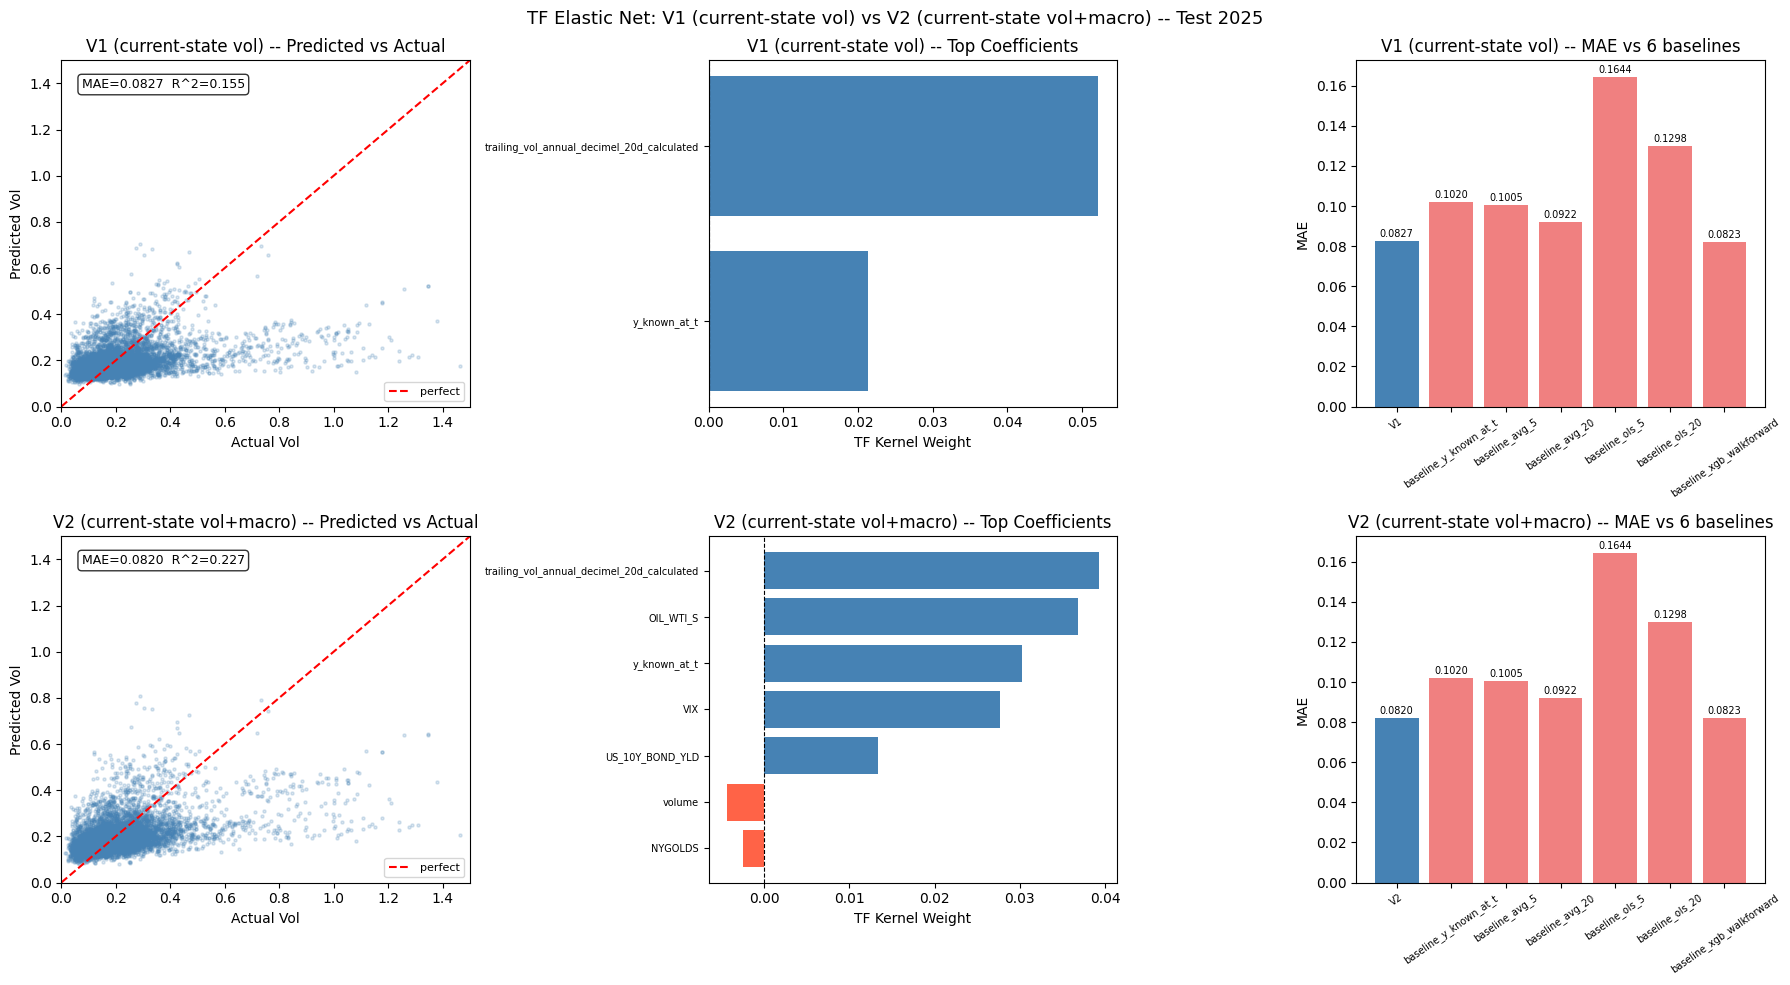

plot saved: elastic_net_tf_v1_v2_comparison.png


In [17]:
# Cell 12 - Plots: V1 vs V2

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'TF Elastic Net: V1 (current-state vol) vs V2 (current-state vol+macro) -- Test 2025',
    fontsize=13
)

for row_idx, (name, res) in enumerate(all_results.items()):
    y_test      = res['y_test']
    y_test_pred = res['y_test_pred']

    coef_df = pd.DataFrame({
        'feature': res['features'],
        'coef':    res['model'].coef_
    }).sort_values('coef', key=abs, ascending=False)

    # col 0: predicted vs actual
    ax = axes[row_idx][0]
    ax.scatter(y_test, y_test_pred, alpha=0.2, s=5, color='steelblue')
    cap = min(max(y_test.max(), y_test_pred.max()) * 1.05, 1.5)
    ax.plot([0, cap], [0, cap], 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel('Actual Vol');  ax.set_ylabel('Predicted Vol')
    ax.set_title(f'{name} -- Predicted vs Actual')
    ax.set_xlim(0, cap);  ax.set_ylim(0, cap)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92,
            f"MAE={res['m_test']['MAE']:.4f}  R^2={res['m_test']['R2']:.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # col 1: top coefficients (retained only)
    ax = axes[row_idx][1]
    top    = coef_df[abs(coef_df['coef']) >= COEF_THRESHOLD].head(12)
    colors = ['tomato' if c < 0 else 'steelblue' for c in top['coef']]
    ax.barh(top['feature'], top['coef'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('TF Kernel Weight')
    ax.set_title(f'{name} -- Top Coefficients')
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

    # col 2: MAE vs baselines (shared rows)
    ax = axes[row_idx][2]
    model_names = [name.split(' ')[0]] + BASELINES
    maes        = [res['m_test']['MAE']]
    for col in BASELINES:
        b    = test_df[col].values
        keep = ~np.isnan(b)
        maes.append(mean_absolute_error(test_df[TARGET].values[keep], b[keep]))
    bar_colors = ['steelblue'] + ['lightcoral'] * len(BASELINES)
    bars = ax.bar(model_names, maes, color=bar_colors)
    ax.set_ylabel('MAE');  ax.set_title(f'{name} -- MAE vs 6 baselines')
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('elastic_net_tf_v1_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved: elastic_net_tf_v1_v2_comparison.png")


**Comment on Output for Cell 12 - Plots: V1 vs V2**

**Predicted Vs Actual**
*  most points are concentrated at lower actual volatility values
*  both models tend to underpredict the very high-volatility observations
*  V2 looks a little better than V1, but the improvement is modest

**Top Coefficients**
*  V1: both features are retained
*  V1: trailing_vol_annual_decimel_20d_calculated larger than y_known_at_t
*  V2: biggest positive weights are on:

trailing_vol_annual_decimel_20d_calculated

OIL_WTI_S

y_known_at_t

VIX
*  V2: small negative weights show up for:

volume

NYGOLDS

**MAE Vs Baselines**
*  V1: slightly worse than baseline_xgb_walkforward
*  V2: slightly better than baseline_xgb_walkforward

## Cell 13 - Subgroup breakdown: market / sector / industry

**Purpose of this cell**

Cell gives results by ETF subgroup.



In [18]:
# Cell 13 - Subgroup breakdown: market / sector / industry
#
# Checks whether V2's macro features help more for some ETF types than others.
# Industry ETFs dominate the dataset, so a win there matters most for overall MAE.

print(f"\n{'Group':<12} {'Version':<22} {'n':>6}  {'MAE':>8}  {'RMSE':>8}  {'R2':>7}")
print('-' * 64)

for grp in ['market', 'sector', 'industry']:
    mask = test_df['group_type'].values == grp
    for name, res in all_results.items():
        sub_y    = res['y_test'][mask]
        sub_pred = res['y_test_pred'][mask]
        if len(sub_y) == 0:
            continue
        mae  = mean_absolute_error(sub_y, sub_pred)
        rmse = np.sqrt(mean_squared_error(sub_y, sub_pred))
        r2   = r2_score(sub_y, sub_pred)
        print(f"{grp:<12} {name:<22} {len(sub_y):>6,}  {mae:>8.4f}  {rmse:>8.4f}  {r2:>7.4f}")
    print()



Group        Version                     n       MAE      RMSE       R2
----------------------------------------------------------------
market       V1 (current-state vol)    245    0.0718    0.1256   0.1550
market       V2 (current-state vol+macro)    245    0.0677    0.1187   0.2457

sector       V1 (current-state vol)  3,185    0.0686    0.1144   0.1457
sector       V2 (current-state vol+macro)  3,185    0.0696    0.1094   0.2195

industry     V1 (current-state vol)  5,390    0.0915    0.1502   0.0985
industry     V2 (current-state vol+macro)  5,390    0.0900    0.1437   0.1751



**Comment on Output for Cell 13 - Subgroup breakdown: market / sector / industry**

**Market group**
*  V1: MAE 0.0718, R2 0.1550
*  V2: MAE 0.0677, R2 0.2457
*  V2 is better than V1

**Sector group**
*  V1: MAE 0.0686, R2 0.1457
*  V2: MAE 0.0696, R2 0.2195
*  V2 helped variance

**Industry group**
*  V1: MAE 0.0915, R2 0.0985
*  V2: MAE 0.0900, R2 0.1751
*  V2 is better than V1


## Cell 14 - Final summary

**Purpose of this cell**

Cell gives final notebook-level takeaway



In [19]:
# Cell 14 - Final summary

print("\n" + "="*65)
print("FINAL SUMMARY  (TensorFlow Elastic Net)")
print("="*65)

for name, res in all_results.items():
    print(f"\n{name}")
    print(f"  candidate features: {res['n_features']}")
    print(f"  retained (|coef|>={COEF_THRESHOLD}): {len(res['kept_features'])}")
    print(f"  near-zero (|coef|< {COEF_THRESHOLD}): {len(res['zeroed_features'])}")
    print(f"  best alpha:     {res['best_alpha']:.6f}")
    print(f"  best l1_ratio:  {res['best_l1ratio']:.2f}  (0=Ridge, 1=Lasso)")
    print(f"  best epoch:     {res['best_epoch']}")
    print(f"  train MAE:      {res['m_train']['MAE']:.4f}  R2={res['m_train']['R2']:.4f}")
    print(f"  test  MAE:      {res['m_test']['MAE']:.4f}  R2={res['m_test']['R2']:.4f}")
    print(f"  overfit gap:    {res['m_test']['MAE'] - res['m_train']['MAE']:+.4f}")

v1_mae = all_results['V1 (current-state vol)']['m_test']['MAE']
v2_mae = all_results['V2 (current-state vol+macro)']['m_test']['MAE']
delta  = v2_mae - v1_mae
pct    = delta / v1_mae * 100

print(f"\n{'='*65}")
print(f"Current macro / market impact (V2 - V1 test MAE):  {delta:+.4f}  ({pct:+.1f}%)")
if delta < 0:
    print("  V2 IMPROVES on V1 -> current macro / market features add predictive value")
elif delta > 0:
    print("  V2 is WORSE than V1 -> current volatility state alone is sufficient")
else:
    print("  No difference")

print("\nLagged features excluded from this notebook by design:")
for f in EXCLUDED_BY_DESIGN: print(f"  - {f}")

print(f"\nBest baseline (shared rows): {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")
print(f"Best baseline (full rows):   {best_bl_full['name']}  MAE={best_bl_full['MAE']:.4f}")
print(f"V1 vs best baseline: {v1_mae - best_bl_shared['MAE']:+.4f}")
print(f"V2 vs best baseline: {v2_mae - best_bl_shared['MAE']:+.4f}")

print(f"\nSplits (per methodology doc 2026-03-07):")
print(f"  train:     {train_df['date'].min().date()} to {train_df['date'].max().date()}  ({len(train_df):,} rows)")
print(f"  val:       {val_df['date'].min().date()} to {val_df['date'].max().date()}  ({len(val_df):,} rows)")
print(f"  test:      {test_df['date'].min().date()} to {test_df['date'].max().date()}  ({len(test_df):,} shared rows)")
print(f"  test_full: {test_full['date'].min().date()} to {test_full['date'].max().date()}  ({len(test_full):,} full rows)")
print("="*65)



FINAL SUMMARY  (TensorFlow Elastic Net)

V1 (current-state vol)
  candidate features: 2
  retained (|coef|>=0.001): 2
  near-zero (|coef|< 0.001): 0
  best alpha:     0.000100
  best l1_ratio:  0.10  (0=Ridge, 1=Lasso)
  best epoch:     51
  train MAE:      0.0795  R2=0.3836
  test  MAE:      0.0827  R2=0.1547
  overfit gap:    +0.0032

V2 (current-state vol+macro)
  candidate features: 8
  retained (|coef|>=0.001): 7
  near-zero (|coef|< 0.001): 1
  best alpha:     0.002976
  best l1_ratio:  0.30  (0=Ridge, 1=Lasso)
  best epoch:     61
  train MAE:      0.0835  R2=0.3357
  test  MAE:      0.0820  R2=0.2273
  overfit gap:    -0.0016

Current macro / market impact (V2 - V1 test MAE):  -0.0007  (-0.8%)
  V2 IMPROVES on V1 -> current macro / market features add predictive value

Lagged features excluded from this notebook by design:
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailin

**Comment on Output for Cell 14 - Final summary**

**Summary of entire model outputs.**

**Conclusion**
* V2 slightly outperformed the best baseline on MAE and more clearly improved R2
